# 1. Zadanie 1: Salud 2030

In [119]:
import time
import copy

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import(
    accuracy_score,
    recall_score,
    precision_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    make_scorer,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

## 1.1 EDA

In [58]:
df = pd.read_csv('./data/ObesityDataSet_raw_and_data_sinthetic.csv')
df.head(20)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [59]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


### Data cleaning

#### Brakujące wartości

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Nie ma brakujących wartości.

#### Duplikaty

In [61]:
print("liczba duplikatów:")
print(df.duplicated().sum())
df[df.duplicated(keep=False)]

liczba duplikatów:
24


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
97,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
105,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
145,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
208,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight


In [62]:
df = df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2087 non-null   str    
 1   Age                             2087 non-null   float64
 2   Height                          2087 non-null   float64
 3   Weight                          2087 non-null   float64
 4   family_history_with_overweight  2087 non-null   str    
 5   FAVC                            2087 non-null   str    
 6   FCVC                            2087 non-null   float64
 7   NCP                             2087 non-null   float64
 8   CAEC                            2087 non-null   str    
 9   SMOKE                           2087 non-null   str    
 10  CH2O                            2087 non-null   float64
 11  SCC                             2087 non-null   str    
 12  FAF                             2087 non-null   fl

In [63]:
# df['FCVC'] 
# df['NCP']
# df['CAEC']
# df['CH2O'] 
# df['FAF']
# df['TUE'], 'CALC', 'MTRANS'].unique()

### Opis kolumn
| Nazwa kolumny | Opis | Rodzaj danych | Możliwe wartości / Zakres |
|---|---|---|---|
| `Gender` | Płeć | Kategoryczna | Kobieta, Mężczyzna |
| `Age` | Wiek | Numeryczna | Wartość numeryczna |
| `Height` | Wzrost | Numeryczna | Wartość numeryczna (w metrach) |
| `Weight` | Waga | Numeryczna | Wartość numeryczna (w kilogramach) |
| `family_history_with_overweight` | Czy członek rodziny cierpiał lub cierpi na nadwagę? | Kategoryczna (binarna) | Tak, Nie |
| `FAVC` | Czy często spożywasz jedzenie wysokokaloryczne? | Kategoryczna (binarna) | Tak, Nie |
| `FCVC` | Czy zazwyczaj jesz warzywa w swoich posiłkach? | Numeryczna | Nigdy, Czasami, Zawsze (zakodowane numerycznie) |
| `NCP` | Ile głównych posiłków jesz w ciągu dnia? | Numeryczna | Między 1 a 2, Trzy, Więcej niż trzy (zakodowane numerycznie) |
| `CAEC` | Czy jesz cokolwiek pomiędzy posiłkami? | Kategoryczna | Nie, Czasami, Często, Zawsze |
| `SMOKE` | Czy palisz papierosy? | Kategoryczna (binarna) | Tak, Nie |
| `CH2O` | Ile wody wypijasz dziennie? | Numeryczna | Mniej niż litr, Między 1 a 2 litry, Więcej niż 2 litry (zakodowane numerycznie) |
| `SCC` | Czy monitorujesz spożywane codziennie kalorie? | Kategoryczna (binarna) | Tak, Nie |
| `FAF` | Jak często podejmujesz aktywność fizyczną? | Numeryczna | Brak, 1 lub 2 dni, 2 do 4 dni, 4 lub 5 dni (zakodowane numerycznie) |
| `TUE` | Ile czasu spędzasz przed urządzeniami technologicznymi takimi jak telefon, gry wideo, telewizja, komputer i inne? | Numeryczna | 0–2 godziny, 3–5 godzin, Więcej niż 5 godzin (zakodowane numerycznie) |
| `CALC` | Jak często pijesz alkohol? | Kategoryczna | Nie piję, Czasami, Często, Zawsze |
| `MTRANS` | Jakiego środka transportu najczęściej używasz? | Kategoryczna | Samochód, Motocykl, Rower, Transport publiczny, Pieszo |
| `NObeyesdad` (kolumna z etykietą klasy) | Poziom otyłości | Kategoryczna | Niedowaga, Waga prawidłowa, Nadwaga I, Nadwaga II, Otyłość I, Otyłość II, Otyłość III |

Text(0.5, 1.0, 'Rozkład klas')

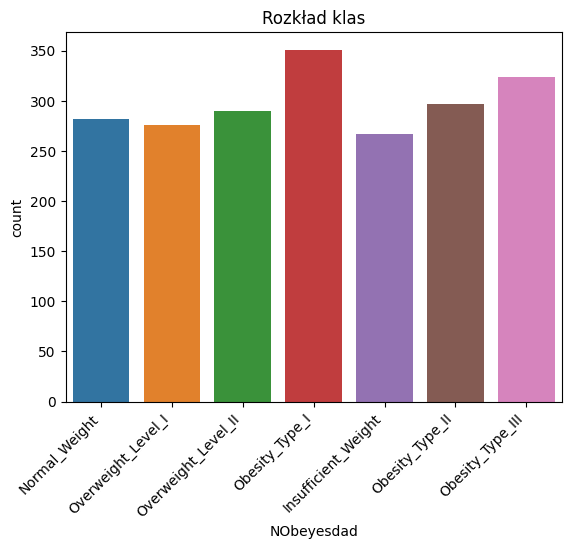

In [64]:
sns.countplot(df, x=df.NObeyesdad, hue='NObeyesdad')
plt.xticks(rotation=45, ha='right')
plt.title('Rozkład klas')

Dane są zrównoważone.

### Rozkład poszczególnych cech

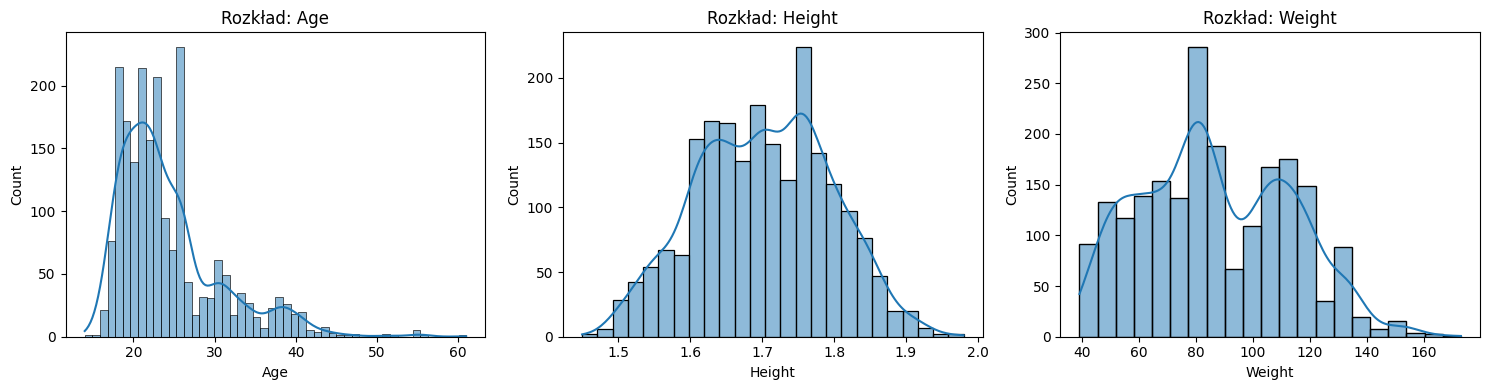

In [65]:
continuous_cols = ['Age', 'Height', 'Weight']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

for i, col in enumerate(continuous_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład: {col}')

plt.tight_layout()
plt.show()



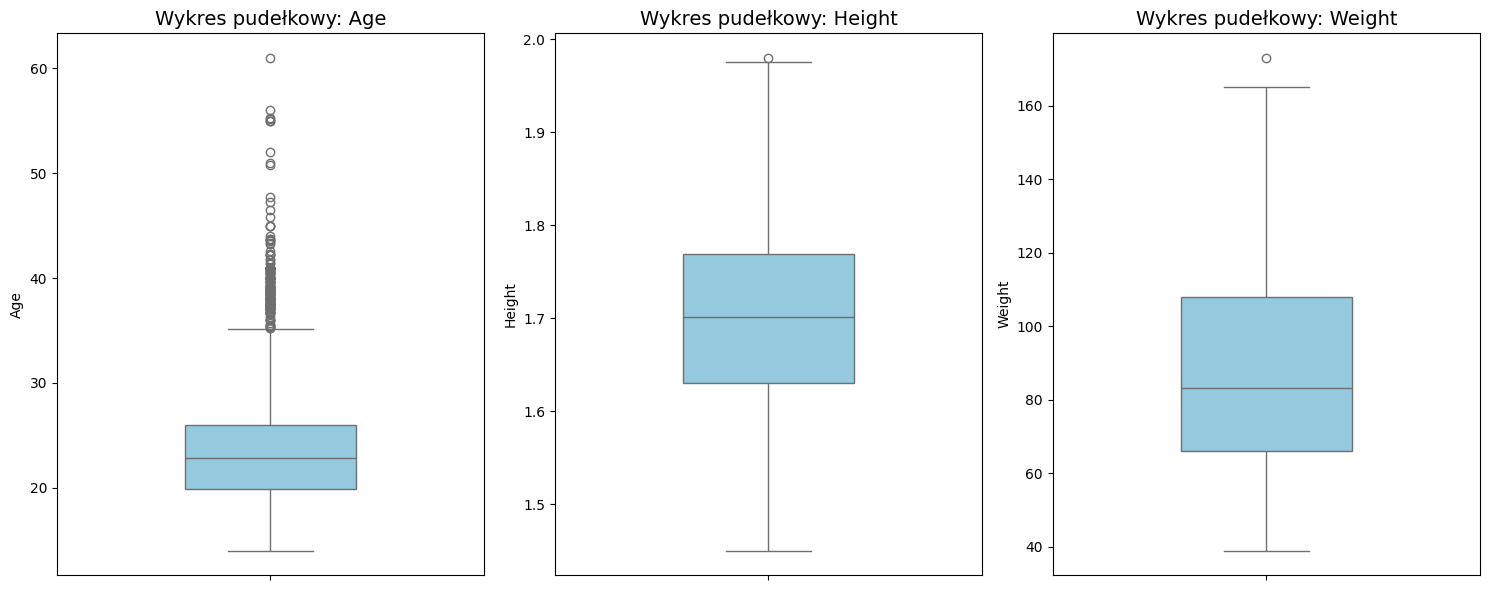

In [66]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue', width=0.4)
    
    axes[i].set_title(f'Wykres pudełkowy: {col}', fontsize=14)

plt.tight_layout()
plt.show()

Raczej czyste dane bez jakichś wymyślnych wartości, które mogłby być błędami.

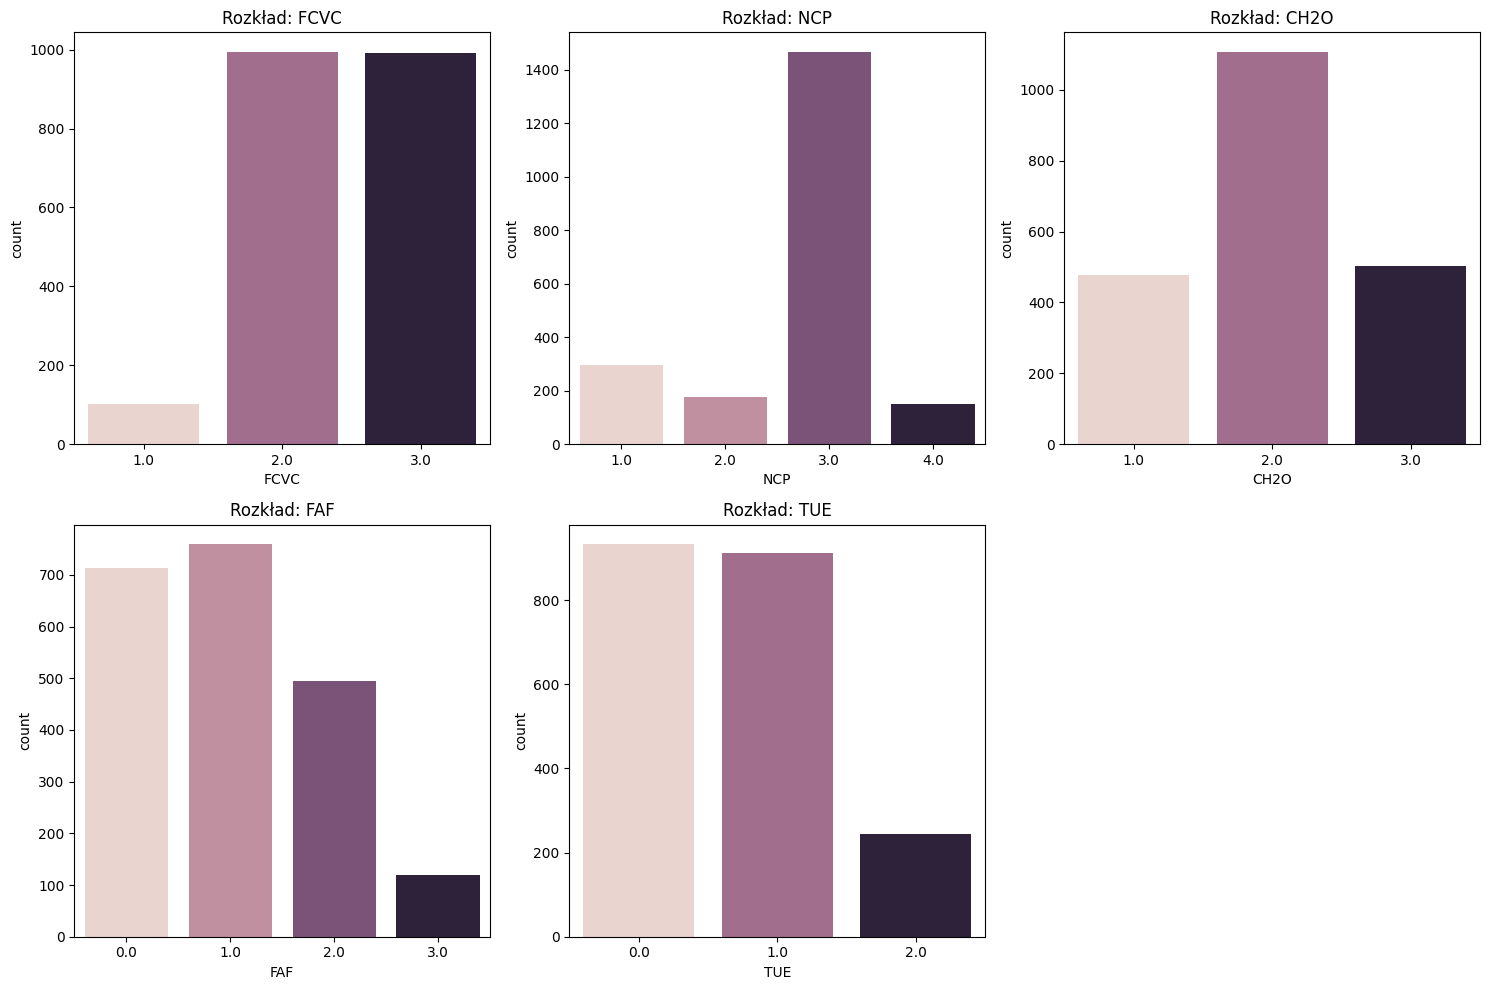

In [67]:
discrete_num_cols = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(discrete_num_cols):
    rounded_data = df[col].round()
    
    sns.countplot(x=rounded_data, ax=axes[i], hue=rounded_data, legend=False)
    axes[i].set_title(f'Rozkład: {col}')
    
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

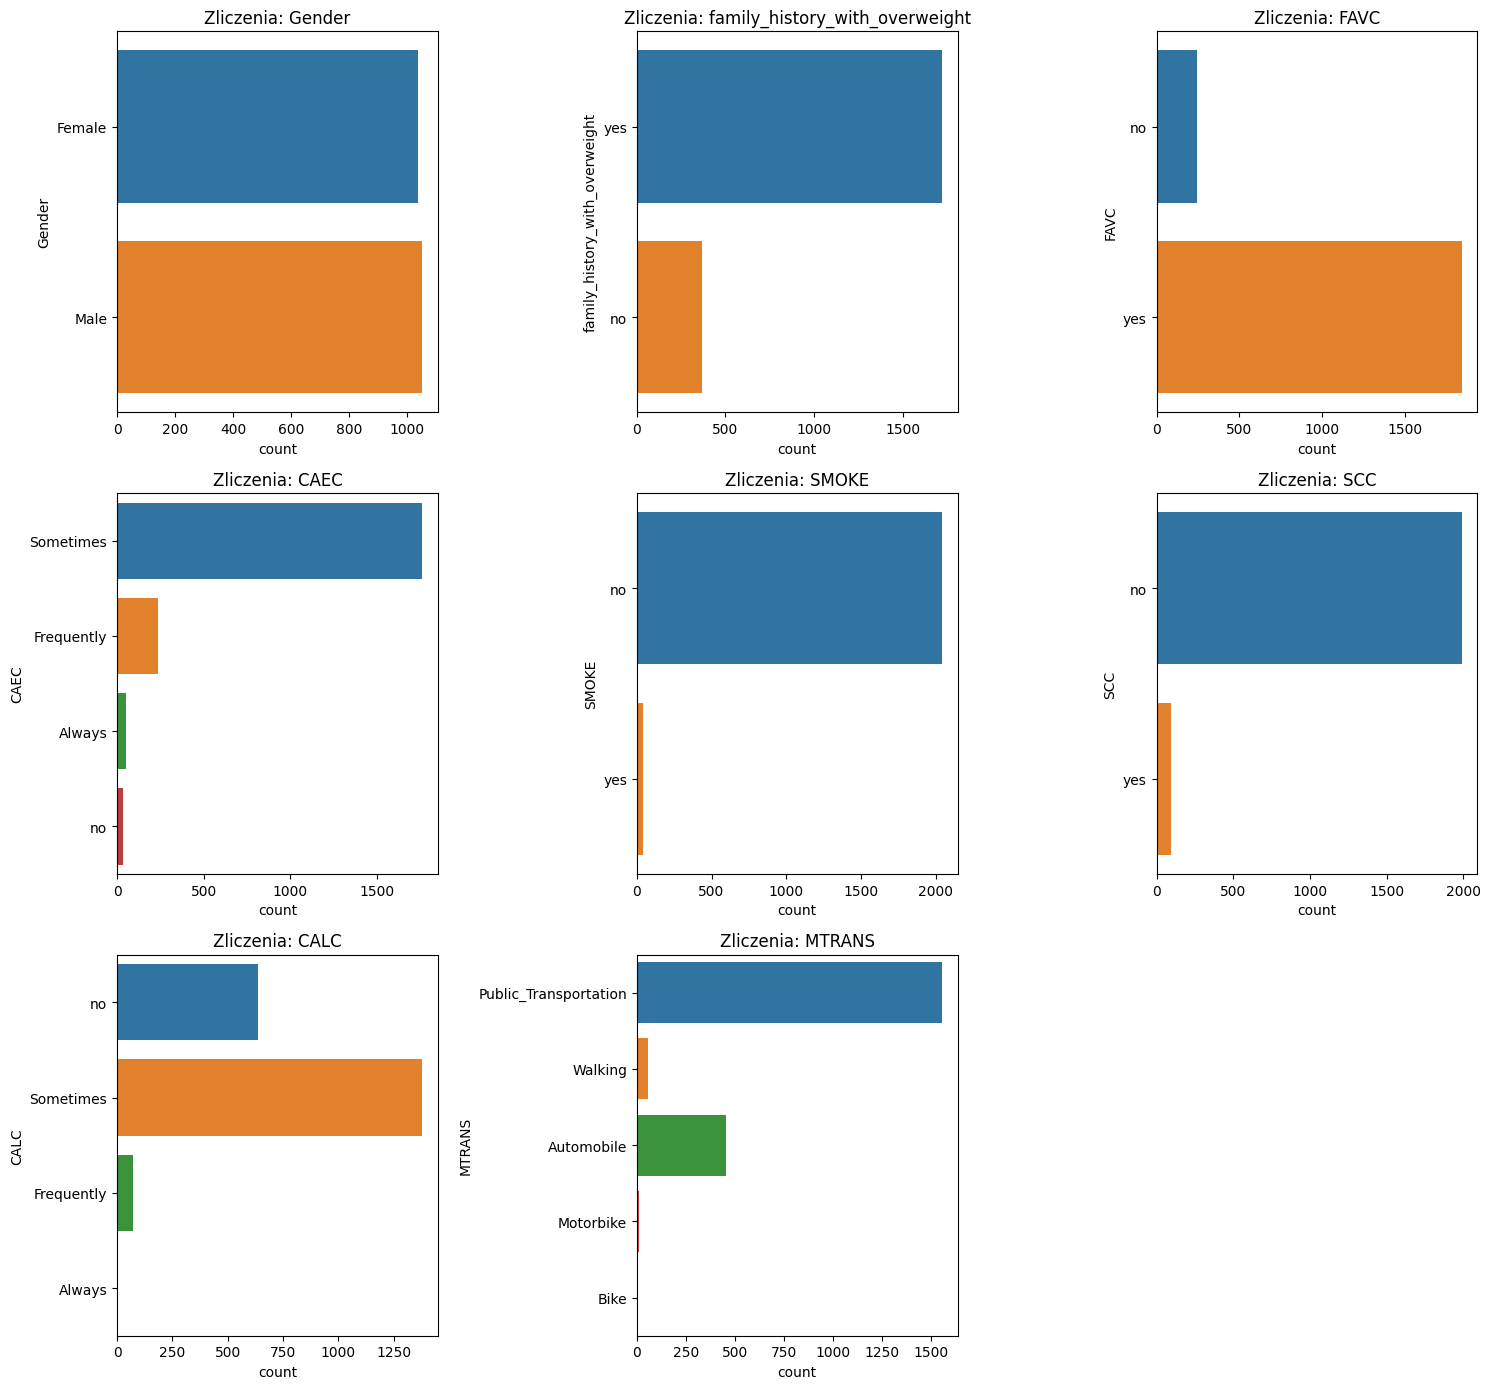

In [68]:
cat_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, y=col, ax=axes[i], hue=col, legend=False)
    axes[i].set_title(f'Zliczenia: {col}')

    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

#### Macierz korelacji

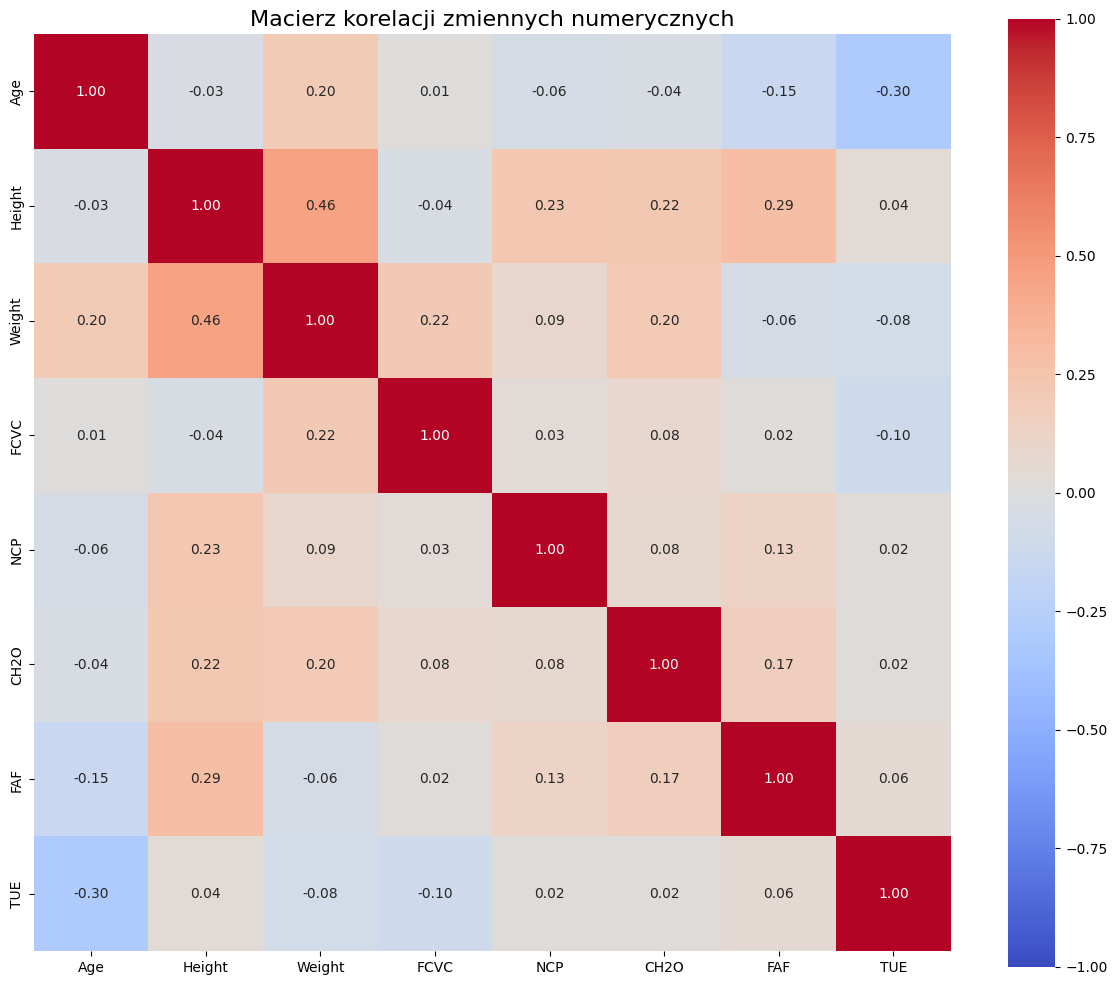

In [69]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0, square=True)

plt.title('Macierz korelacji zmiennych numerycznych', fontsize=16)
plt.tight_layout()
plt.show()

Nie ma jakichś silnie skorelowanych danych wśród zmiennych numerycznych.

### Przekształcanie danych 

In [70]:
df_encoded = df.copy()

obesity_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}
df_encoded['NObeyesdad'] = df_encoded['NObeyesdad'].map(obesity_mapping)

for col in discrete_num_cols:
    df_encoded[col] = df_encoded[col].round()

df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=True)

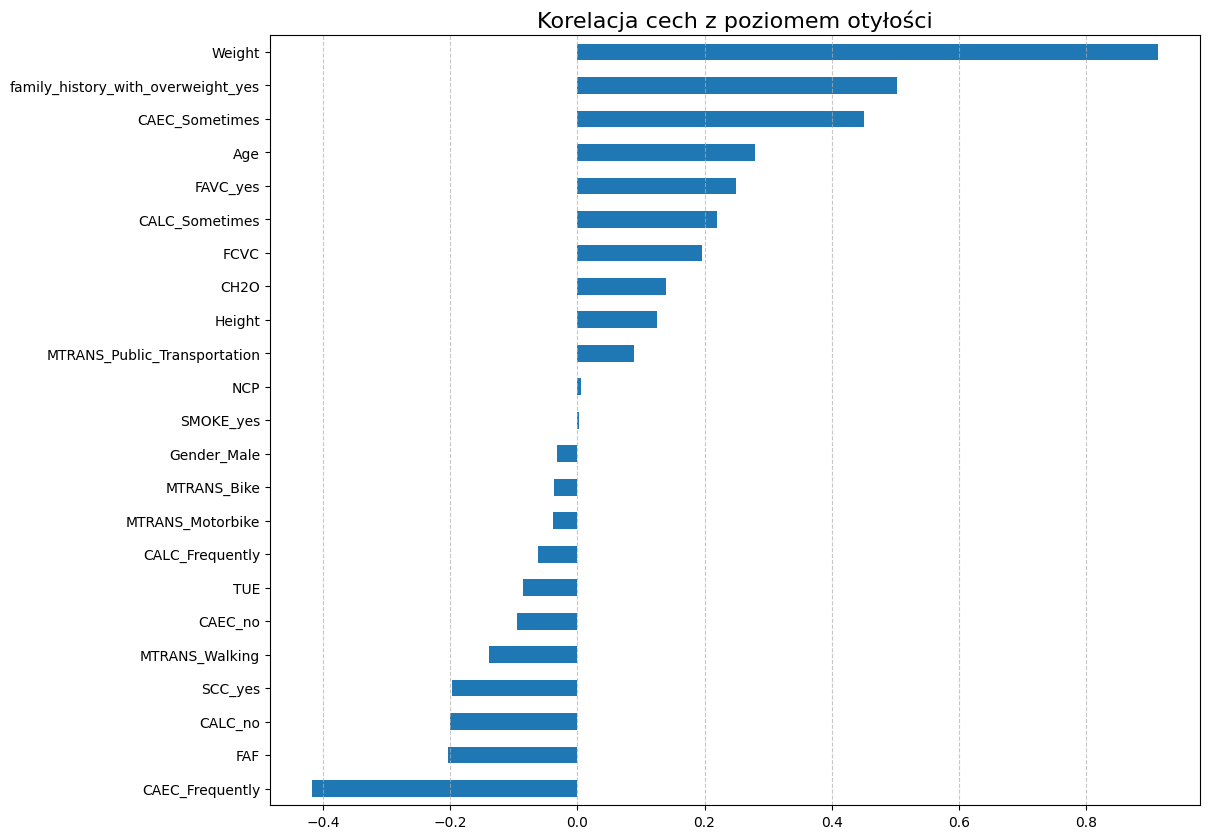

In [71]:
correlations = df_encoded.corr()['NObeyesdad'].drop('NObeyesdad').sort_values()

plt.figure(figsize=(12, 10))

correlations.plot(kind='barh')

plt.title('Korelacja cech z poziomem otyłości', fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Podział danych

In [72]:
X = df_encoded.drop(columns=['NObeyesdad']).copy()
y = df['NObeyesdad'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 1.2 Trenowanie modeli

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Drzewo decyzyjne

In [74]:
tree_model = DecisionTreeClassifier(max_depth=7, random_state=42)

tree_cv_accuracy = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Decision Tree: średnia dokładność na krzyżowej walidacji = {tree_cv_accuracy.mean():.4f}")
tree_cv_recall_m = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_macro')
print(f"Decision Tree: średnia czułość macro na krzyżowej walidacji = {tree_cv_recall_m.mean():.4f}")
tree_cv_recall_w = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_weighted')
print(f"Decision Tree: średnia czułość ważona na krzyżowej walidacji = {tree_cv_recall_w.mean():.4f}")

Decision Tree: średnia dokładność na krzyżowej walidacji = 0.8844
Decision Tree: średnia czułość macro na krzyżowej walidacji = 0.8799
Decision Tree: średnia czułość ważona na krzyżowej walidacji = 0.8844


In [102]:
tree_model.fit(X_train, y_train)
times = []
for _ in range(100):
    start_time = time.perf_counter()
    tree_preds = tree_model.predict(X_test)
    end_time = time.perf_counter()
    times.append(end_time-start_time)
tree_prediction_time = sum(times) / len(times)
print(f"Średni czas predykcji drzewa: {tree_prediction_time:.6f} s")

Średni czas predykcji drzewa: 0.000322 s


In [83]:
print(classification_report(y_test, tree_preds))

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       0.92      0.77      0.84        57
     Obesity_Type_I       0.94      0.96      0.95        70
    Obesity_Type_II       1.00      0.97      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.66      0.91      0.76        55
Overweight_Level_II       0.96      0.78      0.86        58

           accuracy                           0.91       418
          macro avg       0.92      0.91      0.91       418
       weighted avg       0.93      0.91      0.91       418



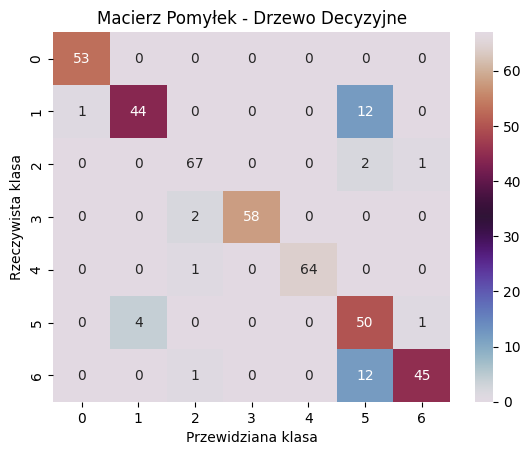

In [76]:
sns.heatmap(confusion_matrix(y_test, tree_preds), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - Drzewo Decyzyjne')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### Regresja logistyczna

In [77]:
logreg_model = LogisticRegression(max_iter=5000, random_state=42)

logreg_cv_accuracy = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Decision Tree: średnia dokładność na krzyżowej walidacji = {logreg_cv_accuracy.mean():.4f}")
logreg_cv_recall_m = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_macro')
print(f"Decision Tree: średnia czułość macro na krzyżowej walidacji = {logreg_cv_recall_m.mean():.4f}")
logreg_cv_recall_w = cross_val_score(tree_model, X_train, y_train, cv=cv, scoring='recall_weighted')
print(f"Decision Tree: średnia czułość ważona na krzyżowej walidacji = {logreg_cv_recall_w.mean():.4f}")

Decision Tree: średnia dokładność na krzyżowej walidacji = 0.8844
Decision Tree: średnia czułość macro na krzyżowej walidacji = 0.8799
Decision Tree: średnia czułość ważona na krzyżowej walidacji = 0.8844


In [109]:
logreg_model.fit(X_train, y_train)

times = []
for _ in range(100):
    start_time = time.perf_counter()
    logreg_preds = logreg_model.predict(X_test)
    end_time = time.perf_counter()
    times.append(end_time-start_time)
logreg_prediction_time = sum(times) / len(times)
print(f"Czas predykcji regresji logistycznej: {logreg_prediction_time:.6f} s")

Czas predykcji regresji logistycznej: 0.000345 s


In [82]:
print(classification_report(y_test, logreg_preds))

                     precision    recall  f1-score   support

Insufficient_Weight       0.93      1.00      0.96        53
      Normal_Weight       0.84      0.81      0.82        57
     Obesity_Type_I       0.90      0.91      0.91        70
    Obesity_Type_II       0.94      0.98      0.96        60
   Obesity_Type_III       0.98      0.98      0.98        65
 Overweight_Level_I       0.79      0.82      0.80        55
Overweight_Level_II       0.84      0.72      0.78        58

           accuracy                           0.89       418
          macro avg       0.89      0.89      0.89       418
       weighted avg       0.89      0.89      0.89       418



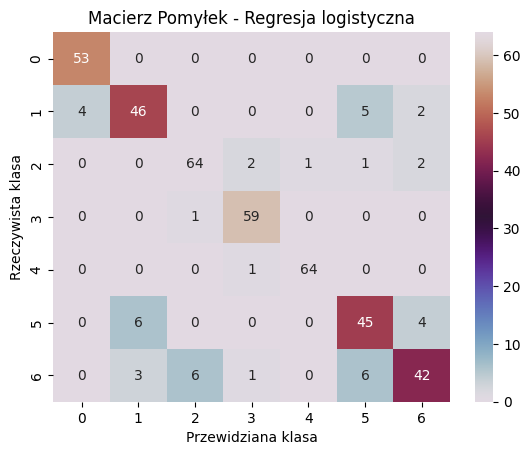

In [79]:
sns.heatmap(confusion_matrix(y_test, logreg_preds), annot=True, fmt='d', cmap='twilight')
plt.title('Macierz Pomyłek - Regresja logistyczna')
plt.xlabel('Przewidziana klasa')
plt.ylabel('Rzeczywista klasa')
plt.show()

### Bagging

In [ ]:
base_shallow_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
base_deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
base_logreg = LogisticRegression(max_iter=1000, random_state=42)

param_grid = {
    'estimator': [base_shallow_tree, base_deep_tree, base_logreg],
    'n_estimators': [10, 25, 50, 100],
    'bootstrap': [True, False],
    'bootstrap_features': [False, True]
}

scoring_metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'F2': make_scorer(fbeta_score, beta=2, average='macro')
}

base_bagging = BaggingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_bagging,
    param_grid=param_grid,
    scoring=scoring_metrics,
    refit='Recall',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


NAJLEPSZY ZBIÓR KLASYFIKATORÓW:
{'bootstrap': True, 'bootstrap_features': True, 'estimator': DecisionTreeClassifier(random_state=42), 'n_estimators': 100}


In [ ]:
print('NAJLEPSZY ZBIÓR KLASYFIKATORÓW:')
print(grid_search.best_params_)
print(f'score: {grid_search.best_score_}')

NAJLEPSZY MODEL BAGGINGU:
base model: Głębokie Drzewo
parameters: {'n_estimators': 25, 'bootstrap': True, 'bootstrap_features': False}
acc: 0.9688995215311005
czas: 0.034538128999884066
